Loading MNIST dataset from local file...
data load finish
Iteration 1, loss = 19.84289103
Iteration 2, loss = 5.07301086
Iteration 3, loss = 3.03008112
Iteration 4, loss = 2.15657011
Iteration 5, loss = 1.38375262
Iteration 6, loss = 0.85135840
Iteration 7, loss = 0.38742106
Iteration 8, loss = 0.10472934
Iteration 9, loss = 0.09934711
Iteration 10, loss = 0.00020709
Iteration 11, loss = 0.00022463
Iteration 12, loss = 0.02243952
Iteration 13, loss = 0.04565668
Iteration 14, loss = 0.00019775
Iteration 15, loss = 0.04047544
Iteration 16, loss = 0.00018912
Iteration 17, loss = 0.00018827
Iteration 18, loss = 0.00896196
Iteration 19, loss = 0.00018331
Iteration 20, loss = 0.00031344
Iteration 21, loss = 0.00018502
Training loss did not improve more than tol=0.000100 for 10 consecutive epochs. Stopping.
MLP accuracy: 0.84


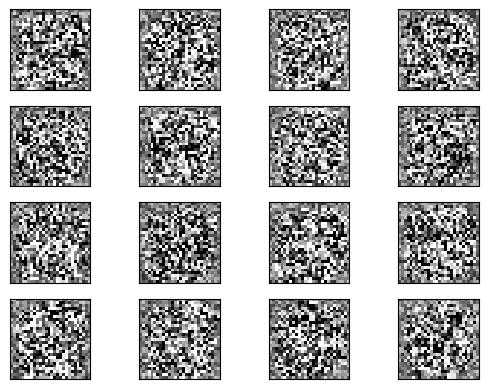

In [1]:
'''
2021/11/25
Sample solution for Lab8 COMP3055 UNNC
Environments:	Python = 3.7.4
		numpy = 1.19.1
		scikit-learn = 0.21.3
		matplotlib = 3.1.1
'''
# ************ Overview ************
# This example demonstrates:
# (1) how to load the MNIST dataset (with a persistent cache),
# (2) train a Multi-Layer Perceptron (MLP) classifier,
# (3) visualize the learned weights of the first hidden layer.

import os
from sklearn.datasets import fetch_openml
import numpy as np

# ************ Load Data ************
# Check if the local dataset file exists
if os.path.exists('mnist.npz'):
    print('Loading MNIST dataset from local file...')
    data = np.load('mnist.npz', allow_pickle=True)
    x_train, y_train, x_test, y_test = data['x_train'], data['y_train'], data['x_test'], data['y_test']
else:
    # Load MNIST using sklearn.fetch_openml
    print('Downloading MNIST dataset using sklearn.fetch_openml()...')
    mnist = fetch_openml('mnist_784', version=1, as_frame=False)

    # The returned dataset has 70000 rows and 784 columns (28x28 images flattened)
    X = mnist['data']  # shape (70000, 784)
    y = mnist['target']
    # Convert types (y may be string dtype depending on sklearn version)
    X = X.astype('uint8')
    y = y.astype('int64')

    # Split into MNIST standard train/test and reshape back to 28x28
    # After this split, x_train/x_test will have shape (-1, 28, 28).
    x_train = X[:60000].reshape((-1, 28, 28))
    y_train = y[:60000]
    x_test = X[60000:].reshape((-1, 28, 28))
    y_test = y[60000:]
    
    # Save a compressed local cache for subsequent convenience
    print('Saving MNIST dataset to local file mnist.npz...')
    np.savez_compressed('mnist.npz', x_train=x_train, y_train=y_train, x_test=x_test, y_test=y_test)

# ************ Subsample & reshape for experimentation ************
# For speed during the lab we only use the first 1000 train / 1000 test samples.
# Flatten images to 1D vectors of length 784 to feed into the MLP.
# Reshape the first 1000 training images from 28x28 matrices to flat vectors of size 784
X_small = np.reshape(x_train[0:1000], (1000,784))
# Select the corresponding first 1000 training labels
Y_small = y_train[0:1000]
# Reshape the first 1000 testing images similarly
X_test = np.reshape(x_test[0:1000], (1000,784))
# Select the corresponding first 1000 testing labels
Y_test = y_test[0:1000]
print('data load finish')

############ Problem I: MLP Classification
# ************ MLP setup & training ************
# We use a Multi-Layer Perceptron (MLP) classifier.
# The hidden layer size is set to 1024.
# Apply MLP classifier
from sklearn.neural_network import MLPClassifier
# Initialize the Multi-Layer Perceptron Classifier
# hidden_layer_sizes=(1024,): One hidden layer with 1024 neurons
# max_iter=1000: Maximum number of iterations for the solver
# solver='adam': Stochastic gradient-based optimizer
# verbose=10: Print progress messages
# learning_rate_init=0.001: Initial learning rate used
mlp = MLPClassifier(hidden_layer_sizes=(1024,),max_iter=1000,solver='adam',verbose=10,learning_rate_init=0.001)
# Train the model using the small training dataset
mlp.fit(X_small, Y_small)
# Evaluate and print the accuracy of the model on the test dataset
print('MLP accuracy:', mlp.score(X_test, Y_test))

############ Problem II: Weight Visualization
# ************ Visualize weights as matrix ************
# We visualize the weights of the first hidden layer to understand what features the network is learning.
# visualize weights as matrix
import matplotlib.pyplot as plt
# Create a 4x4 grid of subplots to display the weights
fig, axes = plt.subplots(4, 4)
# use global min / max to ensure all weights are shown on the same scale
# mlp.coefs_[0] contains the weights connecting the input layer to the first hidden layer
vmin, vmax = mlp.coefs_[0].min(), mlp.coefs_[0].max()
# Iterate over the first 16 neurons in the hidden layer and the subplots
for coef, ax in zip(mlp.coefs_[0].T, axes.ravel()):
    # Reshape the weight vector back to 28x28 to visualize the pattern learned by the neuron
    ax.matshow(coef.reshape(28, 28), cmap=plt.cm.gray, vmin=.5 * vmin, vmax=.5 * vmax)
    # Remove x and y ticks for cleaner visualization
    ax.set_xticks(())
    ax.set_yticks(())
plt.show()